In [5]:
!nvidia-smi

Mon Jun  1 02:57:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.8 MB/s eta 0:00:00


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!ls "/content/drive/MyDrive/disaster_project/day8/disaster_dataset"

images	labels


In [9]:
!ls "/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images"
!ls "/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels"

test  train  val
test  train  train.cache  val  val.cache


In [10]:
!find "/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train" | head -10

/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/flood_frame_7.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/forest_fire_frame_2.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/fire_frame_6.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/fire_frame_3.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/forest_fire_frame_14.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/flood_frame_35.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/forest_fire_frame_17.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/earthquake_frame_14.jpg
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/images/train/earthquake_frame_42.jpg


In [11]:
!find "/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train" | head -10

/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/flood_frame_16.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/forest_fire_frame_7.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/flood_frame_35.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/forest_fire_frame_14.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/fire_frame_3.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/fire_frame_6.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/earthquake_frame_14.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/flood_frame_7.txt
/content/drive/MyDrive/disaster_project/day8/disaster_dataset/labels/train/cyclone_frame_4.txt


In [12]:
%%writefile data.yaml

path: /content/drive/MyDrive/disaster_project/day8/disaster_dataset

train: images/train
val: images/val
test: images/test

names:
  0: earthquake
  1: flood
  2: forest_fire
  3: structural_fire
  4: cyclone

Writing data.yaml


In [13]:
!cat data.yaml


path: /content/drive/MyDrive/disaster_project/day8/disaster_dataset

train: images/train
val: images/val
test: images/test

names:
  0: earthquake
  1: flood
  2: forest_fire
  3: structural_fire
  4: cyclone


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="disaster_segmentation",
    name="yolov8n_seg"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False,

In [15]:
!find /content -name best.pt

/content/runs/segment/disaster_segmentation/yolov8n_seg/weights/best.pt


In [16]:
from google.colab import files
..
files.download(
    "/content/runs/segment/disaster_segmentation/yolov8n_seg/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/disaster_segmentation/yolov8n_seg/weights/best.pt")

results = model.predict(
    source="/content/earthquake_frame_45.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/earthquake_frame_45.jpg: 384x640 1 earthquake, 53.7ms
Speed: 1.8ms preprocess, 53.7ms inference, 8.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/predict


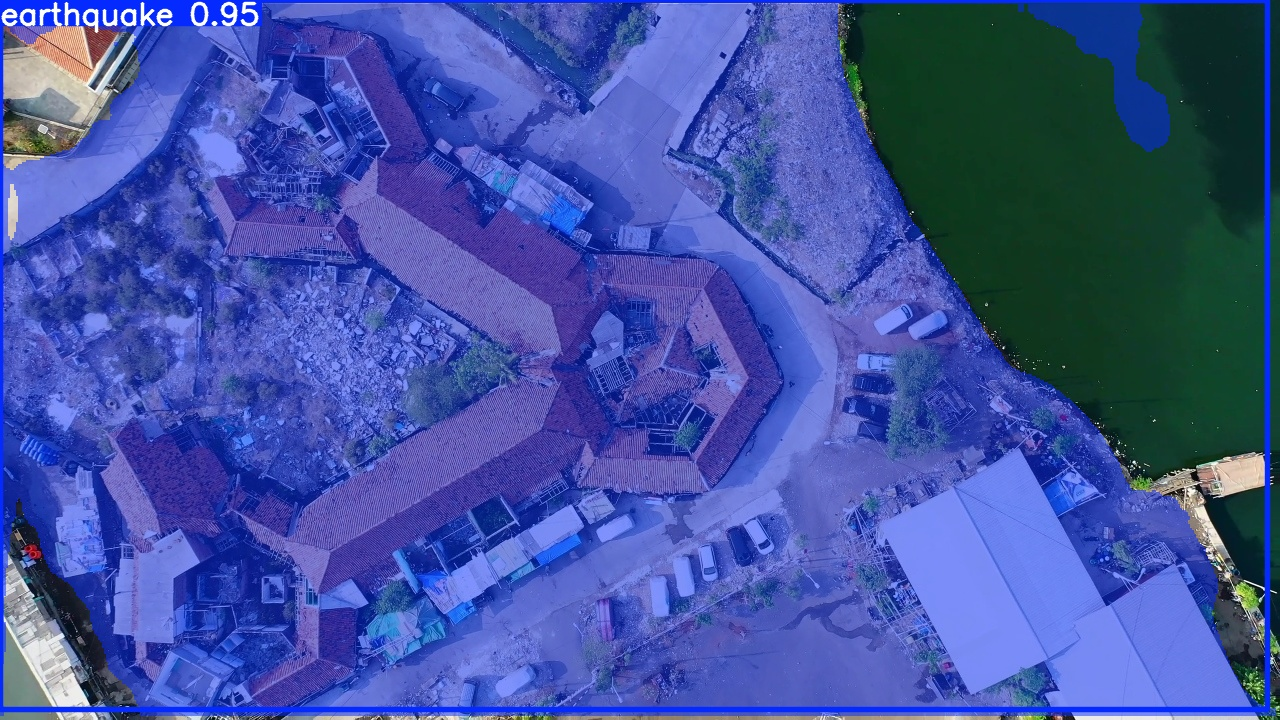

In [18]:
from IPython.display import Image, display

display(Image('/content/runs/segment/predict/earthquake_frame_45.jpg'))

In [29]:
!ls /content

 data.yaml	      earthquake_frame_45.jpg   sample_data
'disaster (1).jfif'   fire_frame_14.jpg         yolo26n.pt
 disaster.jfif	     'forest disaster.jpg'      yolov8n-seg.pt
 drive		      runs


In [26]:
from google.colab import files

uploaded = files.upload()

Saving forest disaster.jpg to forest disaster.jpg
Saving disaster.jfif to disaster (1).jfif


In [28]:
!ls /content

 data.yaml	      earthquake_frame_45.jpg   sample_data
'disaster (1).jfif'   fire_frame_14.jpg         yolo26n.pt
 disaster.jfif	     'forest disaster.jpg'      yolov8n-seg.pt
 drive		      runs


In [37]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/disaster_segmentation/yolov8n_seg/weights/best.pt")

results = model("/content/forest disaster.jpg")


image 1/1 /content/forest disaster.jpg: 416x640 1 forest_fire, 109.7ms
Speed: 4.6ms preprocess, 109.7ms inference, 3.1ms postprocess per image at shape (1, 3, 416, 640)


Now that we have converted the `.jfif` file to `.jpg`, we can try predicting with the `.jpg` file and then display it.

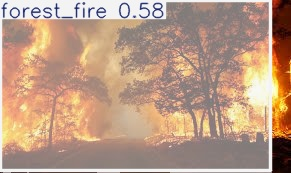

In [41]:
from IPython.display import Image , display
display(Image("/content/runs/segment/predict-2/disaster.jpg"))